This notebook cleans and explores the NorthStar dataset. The aim is to identify data quality issues, prepare the data for analysis, and investigate operational patterns linked to delays, failed deliveries, complaints, incidents and service performance.

**4.1**

In [ ]:
# NorthStar Urban Mobility and Logistics
## Python Data Cleaning and Exploratory Data Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [ ]:
orders = pd.read_csv("orders.csv")
customers = pd.read_csv("customers.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
app_events = pd.read_csv("app_events.csv")

datasets = {
    "orders": orders,
    "customers": customers,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)

orders (1250, 11)
customers (650, 9)
deliveries (950, 13)
drivers (170, 8)
vehicles (120, 8)
hubs (8, 5)
complaints (320, 10)
incidents (280, 7)
app_events (640, 10)


In [ ]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


**4.2 Data Inspection**

In [ ]:

##Looking for missing values and duplicates
for name, df in datasets.items():
    print("\n" + "="*50)
    print(f"Dataset: {name}")
    print("="*50)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())


Dataset: orders
Shape: (1250, 11)

Columns:
['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

Missing values:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Duplicate rows: 0

Dataset: customers
Shape: (650, 9)

Columns:
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

Missing values:
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
p

In [ ]:
for name, df in datasets.items():
    print("Dataset:", name)
    print("Shape:", df.shape)
    print("Missing values:")
    print(df.isnull().sum())
    print("Duplicate rows:", df.duplicated().sum())

Dataset: orders
Shape: (1250, 11)
Missing values:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
Duplicate rows: 0
Dataset: customers
Shape: (650, 9)
Missing values:
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64
Duplicate rows: 0
Dataset: deliveries
Shape: (950, 13)
Missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_complete

In [ ]:
##Check data types:
for name, df in datasets.items():
    print("\n" + "="*50)
    print(f"Dataset: {name}")
    print("="*50)
    print(df.dtypes)


Dataset: orders
order_id                  object
customer_id               object
service_type              object
order_created_at          object
promised_window_hours      int64
pickup_zone               object
dropoff_zone              object
priority_level            object
order_value              float64
booking_channel           object
special_handling_flag      int64
dtype: object

Dataset: customers
customer_id              object
age                       int64
home_zone                object
customer_type            object
signup_date              object
loyalty_score           float64
app_engagement_score    float64
preferred_channel        object
account_status           object
dtype: object

Dataset: deliveries
delivery_id                       object
order_id                          object
driver_id                         object
vehicle_id                        object
hub_id                            object
dispatch_time                     object
delivery_complete

In [ ]:
##Check unique category
categorical_checks = {
    "orders": ["service_type", "pickup_zone", "dropoff_zone", "priority_level", "booking_channel"],
    "customers": ["home_zone", "customer_type", "preferred_channel", "account_status"],
    "deliveries": ["delivery_status"],
    "drivers": ["base_zone", "employment_type", "shift_preference"],
    "vehicles": ["vehicle_type", "assigned_zone", "maintenance_status"],
    "hubs": ["zone", "hub_type"],
    "complaints": ["complaint_type", "channel", "severity", "status"],
    "incidents": ["incident_type", "severity", "resolution_status"],
    "app_events": ["event_type", "device_type", "zone_context"]
}

for dataset_name, columns in categorical_checks.items():
    df = datasets[dataset_name]
    print("\n" + "="*50)
    print(f"Dataset: {dataset_name}")
    print("="*50)

    for col in columns:
        print(f"\n{col}:")
        print(sorted(df[col].dropna().unique()))


Dataset: orders

service_type:
['Business', 'Medical', 'Parcel', 'Passenger', 'Retail']

pickup_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

dropoff_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

priority_level:
['Critical', 'High', 'Low', 'Medium']

booking_channel:
['API', 'App', 'Phone', 'Web']

Dataset: customers

home_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

customer_type:
['Consumer', 'Enterprise', 'SME']

preferred_channel:
['App', 'Partner API', 'Phone', 'Web']

account_status:
['Active', 'Dormant', 'Suspended']

Dataset: deliveries

delivery_status:
['Delayed', 'Failed', 'OnTime']

Dataset: drivers

base_zone:
['AIRPORT', 'Airpor

In [ ]:
##Check unique Id
id_columns = {
    "orders": "order_id",
    "customers": "customer_id",
    "deliveries": "delivery_id",
    "drivers": "driver_id",
    "vehicles": "vehicle_id",
    "hubs": "hub_id",
    "complaints": "complaint_id",
    "incidents": "incident_id",
    "app_events": "event_id"
}

for dataset_name, id_col in id_columns.items():
    df = datasets[dataset_name]
    duplicate_ids = df[id_col].duplicated().sum()
    print(f"{dataset_name}: {duplicate_ids} duplicate {id_col} values")

orders: 0 duplicate order_id values
customers: 0 duplicate customer_id values
deliveries: 0 duplicate delivery_id values
drivers: 0 duplicate driver_id values
vehicles: 0 duplicate vehicle_id values
hubs: 0 duplicate hub_id values
complaints: 0 duplicate complaint_id values
incidents: 0 duplicate incident_id values
app_events: 0 duplicate event_id values


In [ ]:
##Numeric Summary
for name, df in datasets.items():
    print("\n" + "="*50)
    print(f"Dataset: {name}")
    print("="*50)
    display(df.describe(include="number"))


Dataset: orders


,promised_window_hours,order_value,special_handling_flag
count,1250.000000,1250.000000,1250.000000
mean,7.621600,91.050520,0.190400
std,7.057015,60.917783,0.392774
min,1.000000,2.040000,0.000000
25%,4.000000,47.915000,0.000000
50%,6.000000,76.530000,0.000000
75%,12.000000,121.097500,0.000000
max,24.000000,510.060000,1.000000



Dataset: customers


,age,loyalty_score,app_engagement_score
count,650.000000,630.000000,650.000000
mean,46.738462,59.690635,58.132308
std,17.449179,16.124674,18.918154
min,18.000000,13.100000,1.000000
25%,32.000000,49.000000,45.375000
50%,46.000000,59.600000,59.000000
75%,62.000000,70.450000,72.000000
max,78.000000,99.000000,100.000000



Dataset: deliveries


...

,resolution_days,compensation_amount
count,320.000000,304.000000
mean,7.928125,20.257204
std,5.214324,15.002195
min,1.000000,0.000000
25%,3.750000,8.822500
50%,7.000000,18.405000
75%,11.000000,29.145000
max,25.000000,61.850000



Dataset: incidents


,resolved_hours
count,263.000000
mean,12.011407
std,7.751258
min,0.000000
25%,5.150000
50%,11.500000
75%,17.950000
max,41.700000



Dataset: app_events


,api_latency_ms,success_flag
count,640.000000,640.000000
mean,465.667188,0.940625
std,271.634155,0.236510
min,60.000000,0.000000
25%,278.750000,1.000000
50%,432.500000,1.000000
75%,609.000000,1.000000
max,1701.000000,1.000000


**4.3**

**4.3.1**

In [ ]:
# Create copies of the original datasets so the raw data remains unchanged
orders_clean = orders.copy()
customers_clean = customers.copy()
deliveries_clean = deliveries.copy()
drivers_clean = drivers.copy()
vehicles_clean = vehicles.copy()
hubs_clean = hubs.copy()
complaints_clean = complaints.copy()
incidents_clean = incidents.copy()
app_events_clean = app_events.copy()

**4.3.2**

In [ ]:
## Handle missing values

# Create missing-value flags before filling anything
customers_clean["loyalty_score_missing"] = customers_clean["loyalty_score"].isnull().astype(int)
drivers_clean["training_score_missing"] = drivers_clean["training_score"].isnull().astype(int)
vehicles_clean["battery_health_missing"] = vehicles_clean["battery_health_pct"].isnull().astype(int)
deliveries_clean["rating_missing"] = deliveries_clean["customer_rating_post_delivery"].isnull().astype(int)
incidents_clean["resolved_hours_missing"] = incidents_clean["resolved_hours"].isnull().astype(int)

# Handle missing categorical values by labelling them as Unknown
orders_clean["booking_channel"] = orders_clean["booking_channel"].fillna("Unknown")
customers_clean["preferred_channel"] = customers_clean["preferred_channel"].fillna("Unknown")

# Missing compensation is treated as zero because no compensation was recorded
complaints_clean["compensation_amount"] = complaints_clean["compensation_amount"].fillna(0)

# App events can exist without a linked order, so missing order_id is labelled as Not Linked
app_events_clean["order_id"] = app_events_clean["order_id"].fillna("Not Linked")

# Numerical score/rating fields are deliberately left as missing rather than estimated
# This preserves the fact that the value was not recorded in the original dataset

**4.3.3**

In [ ]:
#Standard zone values
def standardise_zone(value):
    if pd.isna(value):
        return value

    value = str(value).strip().lower()

    zone_mapping = {
        "north": "North",
        "south": "South",
        "east": "East",
        "west": "West",
        "central": "Central",
        "ctr": "Central",
        "airport": "Airport",
        "riverside": "Riverside"
    }

    return zone_mapping.get(value, value.title())


# Apply zone standardisation
orders_clean["pickup_zone"] = orders_clean["pickup_zone"].apply(standardise_zone)
orders_clean["dropoff_zone"] = orders_clean["dropoff_zone"].apply(standardise_zone)

customers_clean["home_zone"] = customers_clean["home_zone"].apply(standardise_zone)
drivers_clean["base_zone"] = drivers_clean["base_zone"].apply(standardise_zone)
vehicles_clean["assigned_zone"] = vehicles_clean["assigned_zone"].apply(standardise_zone)
hubs_clean["zone"] = hubs_clean["zone"].apply(standardise_zone)
app_events_clean["zone_context"] = app_events_clean["zone_context"].apply(standardise_zone)

In [ ]:
print("Pickup zones:", sorted(orders_clean["pickup_zone"].unique()))
print("Dropoff zones:", sorted(orders_clean["dropoff_zone"].unique()))
print("Customer home zones:", sorted(customers_clean["home_zone"].unique()))
print("Driver base zones:", sorted(drivers_clean["base_zone"].unique()))

Pickup zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
Dropoff zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
Customer home zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
Driver base zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
#standardising others
# Standardise general categorical text fields
orders_clean["service_type"] = orders_clean["service_type"].str.strip().str.title()
orders_clean["priority_level"] = orders_clean["priority_level"].str.strip().str.title()
orders_clean["booking_channel"] = orders_clean["booking_channel"].str.strip().str.title()

deliveries_clean["delivery_status"] = deliveries_clean["delivery_status"].str.strip().str.title()

drivers_clean["employment_type"] = drivers_clean["employment_type"].str.strip().str.title()
drivers_clean["shift_preference"] = drivers_clean["shift_preference"].str.strip().str.title()

vehicles_clean["vehicle_type"] = vehicles_clean["vehicle_type"].str.strip().str.title()
vehicles_clean["maintenance_status"] = vehicles_clean["maintenance_status"].str.strip().str.title()

complaints_clean["complaint_type"] = complaints_clean["complaint_type"].str.strip().str.title()
complaints_clean["channel"] = complaints_clean["channel"].str.strip().str.title()
complaints_clean["severity"] = complaints_clean["severity"].str.strip().str.title()
complaints_clean["status"] = complaints_clean["status"].str.strip().str.title()

incidents_clean["incident_type"] = incidents_clean["incident_type"].str.strip().str.title()
incidents_clean["severity"] = incidents_clean["severity"].str.strip().str.title()
incidents_clean["resolution_status"] = incidents_clean["resolution_status"].str.strip().str.title()

app_events_clean["event_type"] = app_events_clean["event_type"].str.strip().str.title()
app_events_clean["device_type"] = app_events_clean["device_type"].str.strip().str.title()

**4.3.4**

In [ ]:
#Converting dates
# Convert date and time columns into datetime format
orders_clean["order_created_at"] = pd.to_datetime(orders_clean["order_created_at"], errors="coerce")
customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"], errors="coerce")

deliveries_clean["dispatch_time"] = pd.to_datetime(deliveries_clean["dispatch_time"], errors="coerce")
deliveries_clean["delivery_completed_at"] = pd.to_datetime(deliveries_clean["delivery_completed_at"], errors="coerce")

vehicles_clean["commission_date"] = pd.to_datetime(vehicles_clean["commission_date"], errors="coerce")

complaints_clean["created_at"] = pd.to_datetime(complaints_clean["created_at"], errors="coerce")
incidents_clean["reported_at"] = pd.to_datetime(incidents_clean["reported_at"], errors="coerce")
app_events_clean["event_timestamp"] = pd.to_datetime(app_events_clean["event_timestamp"], errors="coerce")

In [ ]:
date_columns = {
    "orders_clean": orders_clean["order_created_at"],
    "customers_clean": customers_clean["signup_date"],
    "deliveries_dispatch": deliveries_clean["dispatch_time"],
    "deliveries_completed": deliveries_clean["delivery_completed_at"],
    "complaints_clean": complaints_clean["created_at"],
    "incidents_clean": incidents_clean["reported_at"],
    "app_events_clean": app_events_clean["event_timestamp"]
}

for name, col in date_columns.items():
    print(name, col.dtype)

orders_clean datetime64[ns]
customers_clean datetime64[ns]
deliveries_dispatch datetime64[ns]
deliveries_completed datetime64[ns]
complaints_clean datetime64[ns]
incidents_clean datetime64[ns]
app_events_clean datetime64[ns]


**4.3.5**

In [ ]:
#Numerical values
numeric_columns = {
    "orders_clean": ["promised_window_hours", "order_value", "special_handling_flag"],
    "customers_clean": ["age", "loyalty_score", "app_engagement_score"],
    "deliveries_clean": [
        "route_distance_km",
        "manual_route_override_count",
        "proof_of_completion_missing",
        "customer_rating_post_delivery",
        "fuel_or_charge_cost"
    ],
    "drivers_clean": ["years_experience", "training_score", "driver_rating", "active_flag"],
    "vehicles_clean": ["battery_health_pct", "odometer_km"],
    "hubs_clean": ["capacity_score"],
    "complaints_clean": ["resolution_days", "compensation_amount"],
    "incidents_clean": ["resolved_hours"],
    "app_events_clean": ["api_latency_ms", "success_flag"]
}

cleaned_datasets = {
    "orders_clean": orders_clean,
    "customers_clean": customers_clean,
    "deliveries_clean": deliveries_clean,
    "drivers_clean": drivers_clean,
    "vehicles_clean": vehicles_clean,
    "hubs_clean": hubs_clean,
    "complaints_clean": complaints_clean,
    "incidents_clean": incidents_clean,
    "app_events_clean": app_events_clean
}

for dataset_name, columns in numeric_columns.items():
    df = cleaned_datasets[dataset_name]
    for col in columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

**4.3.6**

In [ ]:
#Deliveries
# Recalculate raw delivery duration first
deliveries_clean["raw_delivery_duration_hours"] = (
    deliveries_clean["delivery_completed_at"] - deliveries_clean["dispatch_time"]
).dt.total_seconds() / 3600

# Flag negative durations before replacing them
deliveries_clean["invalid_delivery_duration"] = np.where(
    deliveries_clean["raw_delivery_duration_hours"] < 0,
    1,
    0
)

# Create cleaned duration column
deliveries_clean["delivery_duration_hours"] = deliveries_clean["raw_delivery_duration_hours"]

# Replace negative durations with NaN so they do not distort analysis
deliveries_clean.loc[
    deliveries_clean["delivery_duration_hours"] < 0,
    "delivery_duration_hours"
] = np.nan

# Round duration
deliveries_clean["delivery_duration_hours"] = deliveries_clean["delivery_duration_hours"].round(2)

print("Missing completed dates:", deliveries_clean["delivery_completed_at"].isnull().sum())
print("Invalid negative durations:", deliveries_clean["invalid_delivery_duration"].sum())
print("Missing cleaned delivery durations:", deliveries_clean["delivery_duration_hours"].isnull().sum())

Missing completed dates: 19
Invalid negative durations: 64
Missing cleaned delivery durations: 83


**Validation**

In [ ]:
for name, df in cleaned_datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print("Missing values after cleaning:")
    print(df.isnull().sum())


orders_clean
Missing values after cleaning:
order_id                 0
customer_id              0
service_type             0
order_created_at         0
promised_window_hours    0
pickup_zone              0
dropoff_zone             0
priority_level           0
order_value              0
booking_channel          0
special_handling_flag    0
dtype: int64

customers_clean
Missing values after cleaning:
customer_id               0
age                       0
home_zone                 0
customer_type             0
signup_date               0
loyalty_score            20
app_engagement_score      0
preferred_channel         0
account_status            0
loyalty_score_missing     0
dtype: int64

deliveries_clean
Missing values after cleaning:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
del

In [ ]:
print("Invalid delivery durations:", deliveries_clean["invalid_delivery_duration"].sum())
print("Missing completed dates:", deliveries_clean["delivery_completed_at"].isnull().sum())
print("Missing cleaned delivery durations:", deliveries_clean["delivery_duration_hours"].isnull().sum())
print("Missing raw delivery durations:", deliveries_clean["raw_delivery_duration_hours"].isnull().sum())

Invalid delivery durations: 64
Missing completed dates: 19
Missing cleaned delivery durations: 83
Missing raw delivery durations: 19


 **4.4 Feature Engineering for Operational Analysis**

This section creates new fields to support analysis of NorthStar's operational performance, including delivery failures, manual route overrides, customer complaints, incidents and app performance.**

In [ ]:
# Create delivery outcome flags
deliveries_clean["failed_delivery_flag"] = np.where(
    deliveries_clean["delivery_status"].str.lower().isin(["failed", "cancelled", "exception"]),
    1,
    0
)

deliveries_clean["completed_delivery_flag"] = np.where(
    deliveries_clean["delivery_status"].str.lower().isin(["completed", "delivered", "success"]),
    1,
    0
)

deliveries_clean["manual_override_flag"] = np.where(
    deliveries_clean["manual_route_override_count"] > 0,
    1,
    0
)

deliveries_clean["high_override_flag"] = np.where(
    deliveries_clean["manual_route_override_count"] >= 3,
    1,
    0
)

In [ ]:
deliveries_clean["delivery_status"].value_counts()

,count
delivery_status,
Ontime,616
Delayed,202
Failed,132


In [ ]:
# Create month/year features for trend analysis
orders_clean["order_month"] = orders_clean["order_created_at"].dt.to_period("M").astype(str)
deliveries_clean["dispatch_month"] = deliveries_clean["dispatch_time"].dt.to_period("M").astype(str)
complaints_clean["complaint_month"] = complaints_clean["created_at"].dt.to_period("M").astype(str)
incidents_clean["incident_month"] = incidents_clean["reported_at"].dt.to_period("M").astype(str)
app_events_clean["event_month"] = app_events_clean["event_timestamp"].dt.to_period("M").astype(str)

# Create hour features for operational pattern analysis
orders_clean["order_hour"] = orders_clean["order_created_at"].dt.hour
deliveries_clean["dispatch_hour"] = deliveries_clean["dispatch_time"].dt.hour
app_events_clean["event_hour"] = app_events_clean["event_timestamp"].dt.hour

In [ ]:
# Create complaint flag at order level
orders_clean["complaint_flag"] = np.where(
    orders_clean["order_id"].isin(complaints_clean["order_id"]),
    1,
    0
)

# Create incident flag at delivery level
deliveries_clean["incident_flag"] = np.where(
    deliveries_clean["delivery_id"].isin(incidents_clean["delivery_id"]),
    1,
    0
)

In [ ]:
# Create app event performance flags
app_events_clean["failed_app_event_flag"] = np.where(
    app_events_clean["success_flag"] == 0,
    1,
    0
)

app_events_clean["high_latency_flag"] = np.where(
    app_events_clean["api_latency_ms"] >= app_events_clean["api_latency_ms"].quantile(0.75),
    1,
    0
)

In [ ]:
# Combine orders with customers
orders_customers = orders_clean.merge(
    customers_clean,
    on="customer_id",
    how="left"
)

# Combine deliveries with orders and customers
delivery_analysis = deliveries_clean.merge(
    orders_clean,
    on="order_id",
    how="left"
).merge(
    customers_clean,
    on="customer_id",
    how="left"
).merge(
    drivers_clean,
    on="driver_id",
    how="left"
).merge(
    vehicles_clean,
    on="vehicle_id",
    how="left"
).merge(
    hubs_clean,
    on="hub_id",
    how="left",
    suffixes=("", "_hub")
)

delivery_analysis.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,rating_missing,raw_delivery_duration_hours,invalid_delivery_duration,delivery_duration_hours,failed_delivery_flag,completed_delivery_flag,manual_override_flag,high_override_flag,dispatch_month,dispatch_hour,incident_flag,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,order_month,order_hour,complaint_flag,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,loyalty_score_missing,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,training_score_missing,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,battery_health_missing,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,0,22.149973,0,22.15,1,0,1,0,2024-06,10,1,C0567,Business,2024-06-18 09:48:00,6,Central,Central,Medium,151.14,Web,0,2024-06,9,0,74,East,Consumer,2024-02-18 04:31:00,79.7,64.9,App,Active,0,Airport,Parttime,13,88.9,4.75,Morning,1,0,Ev,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2,0,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,Ontime,10.34,1,0,5.00,13.41,0,-1.100000,1,NaN,0,0,1,0,2025-01,18,0,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1,2025-01,17,0,50,North,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,0,Central,Parttime,11,69.2,4.61,Evening,1,0,Diesel,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,0,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,Ontime,7.92,0,0,4.98,8.51,0,1.108991,0,1.11,0,0,0,0,2025-06,20,0,C0480,Medical,2025-06-02 19:12:00,2,Central,North,Medium,141.93,Web,0,2025-06,19,0,26,North,Enterprise,2025-03-02 00:55:00,67.6,49.6,App,Dormant,0,Central,Fulltime,8,78.8,4.38,Flexible,1,0,Diesel,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,0,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,0,23.985584,0,23.99,0,0,0,0,2024-03,23,0,C0616,Medical,2024-03-08 20:58:00,24,South,North,Low,11.11,App,0,2024-03,20,0,49,Riverside,Consumer,2024-11-30 06:56:00,65.9,78.2,Phone,Active,0,Central,Fulltime,4,58.2,4.19,Morning,1,0,Hybrid,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,0,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,Ontime,14.52,1,0,4.18,9.22,0,4.042814,0,4.04,0,0,1,0,2025-09,11,0,C0276,Medical,2025-09-21 09:29:00,6,Riverside,Riverside,High,76.02,App,0,2025-09,9,0,47,South,Consumer,2024-11-15 02:59:00,66.9,76.6,App,Active,0,South,Fulltime,10,70.6,4.33,Morning,1,0,Ev,Riverside,2025-05-24 09:58:00,94.2,210683,Inrepair,v2.0,0,North Exchange,North,Dispatch,82


In [ ]:
# Add incident counts per delivery
incident_counts = incidents_clean.groupby("delivery_id").size().reset_index(name="incident_count")

delivery_analysis = delivery_analysis.merge(
    incident_counts,
    on="delivery_id",
    how="left"
)

delivery_analysis["incident_count"] = delivery_analysis["incident_count"].fillna(0).astype(int)

# Add complaint counts per order
complaint_counts = complaints_clean.groupby("order_id").size().reset_index(name="complaint_count")

delivery_analysis = delivery_analysis.merge(
    complaint_counts,
    on="order_id",
    how="left"
)

delivery_analysis["complaint_count"] = delivery_analysis["complaint_count"].fillna(0).astype(int)

delivery_analysis.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,rating_missing,raw_delivery_duration_hours,invalid_delivery_duration,delivery_duration_hours,failed_delivery_flag,completed_delivery_flag,manual_override_flag,high_override_flag,dispatch_month,dispatch_hour,incident_flag,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,order_month,order_hour,complaint_flag,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,loyalty_score_missing,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,training_score_missing,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,battery_health_missing,hub_name,zone,hub_type,capacity_score,incident_count,complaint_count
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,0,22.149973,0,22.15,1,0,1,0,2024-06,10,1,C0567,Business,2024-06-18 09:48:00,6,Central,Central,Medium,151.14,Web,0,2024-06,9,0,74,East,Consumer,2024-02-18 04:31:00,79.7,64.9,App,Active,0,Airport,Parttime,13,88.9,4.75,Morning,1,0,Ev,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2,0,Central Core,Central,Control,88,1,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,Ontime,10.34,1,0,5.00,13.41,0,-1.100000,1,NaN,0,0,1,0,2025-01,18,0,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1,2025-01,17,0,50,North,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,0,Central,Parttime,11,69.2,4.61,Evening,1,0,Diesel,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,0,South Link,South,Dispatch,78,0,0
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,Ontime,7.92,0,0,4.98,8.51,0,1.108991,0,1.11,0,0,0,0,2025-06,20,0,C0480,Medical,2025-06-02 19:12:00,2,Central,North,Medium,141.93,Web,0,2025-06,19,0,26,North,Enterprise,2025-03-02 00:55:00,67.6,49.6,App,Dormant,0,Central,Fulltime,8,78.8,4.38,Flexible,1,0,Diesel,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,0,South Link,South,Dispatch,78,0,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,0,23.985584,0,23.99,0,0,0,0,2024-03,23,0,C0616,Medical,2024-03-08 20:58:00,24,South,North,Low,11.11,App,0,2024-03,20,0,49,Riverside,Consumer,2024-11-30 06:56:00,65.9,78.2,Phone,Active,0,Central,Fulltime,4,58.2,4.19,Morning,1,0,Hybrid,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,0,South Link,South,Dispatch,78,0,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,Ontime,14.52,1,0,4.18,9.22,0,4.042814,0,4.04,0,0,1,0,2025-09,11,0,C0276,Medical,2025-09-21 09:29:00,6,Riverside,Riverside,High,76.02,App,0,2025-09,9,0,47,South,Consumer,2024-11-15 02:59:00,66.9,76.6,App,Active,0,South,Fulltime,10,70.6,4.33,Morning,1,0,Ev,Riverside,2025-05-24 09:58:00,94.2,210683,Inrepair,v2.0,0,North Exchange,North,Dispatch,82,0,0


delivery_status
Ontime     616
Delayed    202
Failed     132
Name: count, dtype: int64


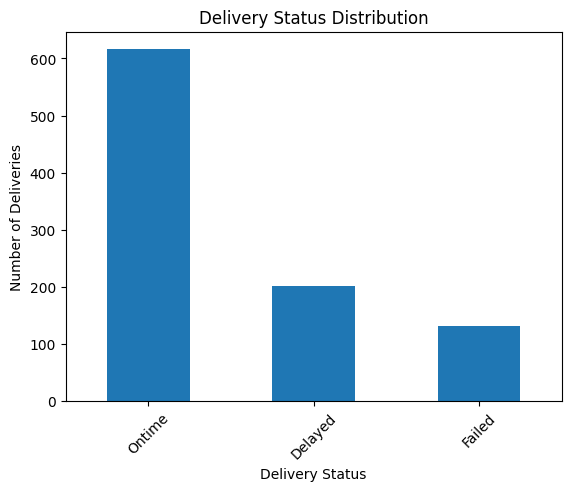

In [ ]:
delivery_status_counts = deliveries_clean["delivery_status"].value_counts()

print(delivery_status_counts)

delivery_status_counts.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.show()

manual_override_flag
0    10.440542
1    10.225643
Name: delivery_duration_hours, dtype: float64


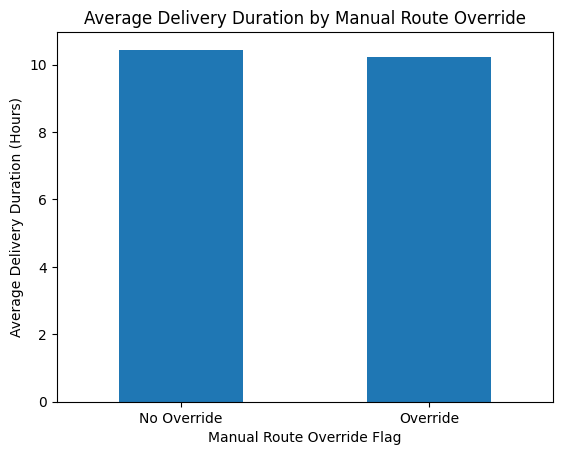

In [ ]:
override_duration = delivery_analysis.groupby("manual_override_flag")["delivery_duration_hours"].mean()

print(override_duration)

override_duration.plot(kind="bar")
plt.title("Average Delivery Duration by Manual Route Override")
plt.xlabel("Manual Route Override Flag")
plt.ylabel("Average Delivery Duration (Hours)")
plt.xticks([0, 1], ["No Override", "Override"], rotation=0)
plt.show()

complaint_type
Delay                101
Missedpickup          64
Appissue              53
Driverbehaviour       51
Supportexperience     20
Billing               16
Damage                15
Name: count, dtype: int64


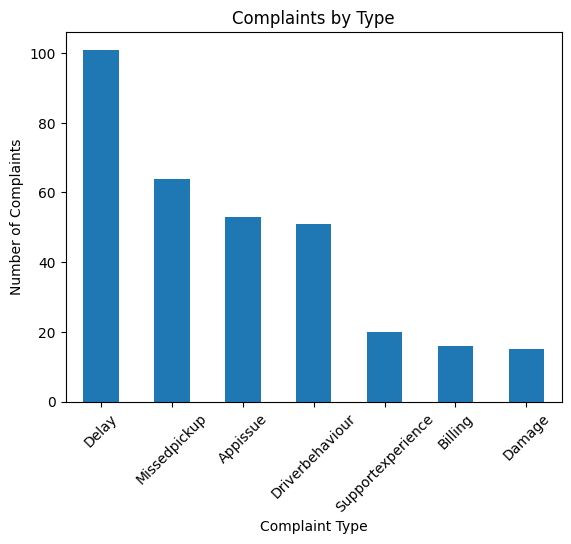

In [ ]:
complaints_by_type = complaints_clean["complaint_type"].value_counts()

print(complaints_by_type)

complaints_by_type.plot(kind="bar")
plt.title("Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

severity
Medium    172
High       77
Low        71
Name: count, dtype: int64


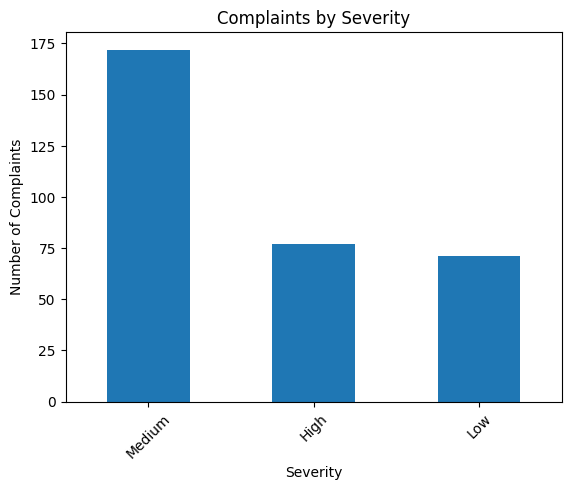

In [ ]:
complaints_by_severity = complaints_clean["severity"].value_counts()

print(complaints_by_severity)

complaints_by_severity.plot(kind="bar")
plt.title("Complaints by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

In [ ]:
app_success_rate = app_events_clean["success_flag"].mean() * 100

print("App event success rate:", round(app_success_rate, 2), "%")

App event success rate: 94.06 %


event_type
Delivery_Instruction_Update    496.293333
Chat_Opened                    478.329545
Chat_Escalated                 478.131579
Payment_Retry                  472.681159
Track_Order                    460.710145
Search_Route                   456.505051
Eta_Refresh                    452.152381
Cancel_Attempt                 417.142857
Name: api_latency_ms, dtype: float64


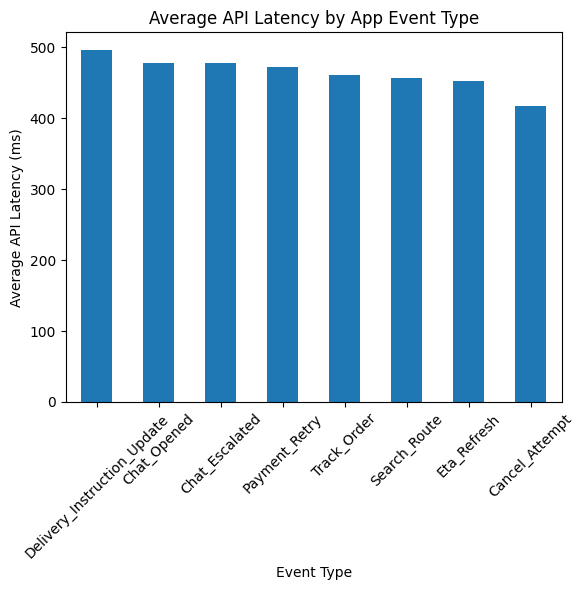

In [ ]:
latency_by_event = app_events_clean.groupby("event_type")["api_latency_ms"].mean().sort_values(ascending=False)

print(latency_by_event)

latency_by_event.plot(kind="bar")
plt.title("Average API Latency by App Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average API Latency (ms)")
plt.xticks(rotation=45)
plt.show()

zone
West         11.102414
Central      11.035044
North        10.684915
Riverside    10.535648
Airport       9.917158
South         9.478866
East          8.438131
Name: delivery_duration_hours, dtype: float64


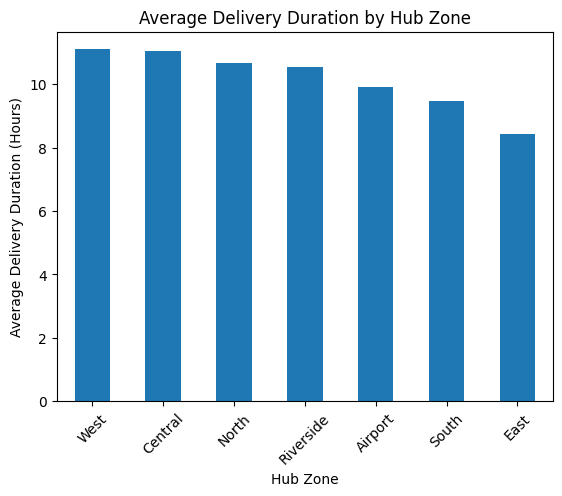

In [ ]:
duration_by_zone = delivery_analysis.groupby("zone")["delivery_duration_hours"].mean().sort_values(ascending=False)

print(duration_by_zone)

duration_by_zone.plot(kind="bar")
plt.title("Average Delivery Duration by Hub Zone")
plt.xlabel("Hub Zone")
plt.ylabel("Average Delivery Duration (Hours)")
plt.xticks(rotation=45)
plt.show()

event_type
Delivery_Instruction_Update    496.293333
Chat_Opened                    478.329545
Chat_Escalated                 478.131579
Payment_Retry                  472.681159
Track_Order                    460.710145
Search_Route                   456.505051
Eta_Refresh                    452.152381
Cancel_Attempt                 417.142857
Name: api_latency_ms, dtype: float64


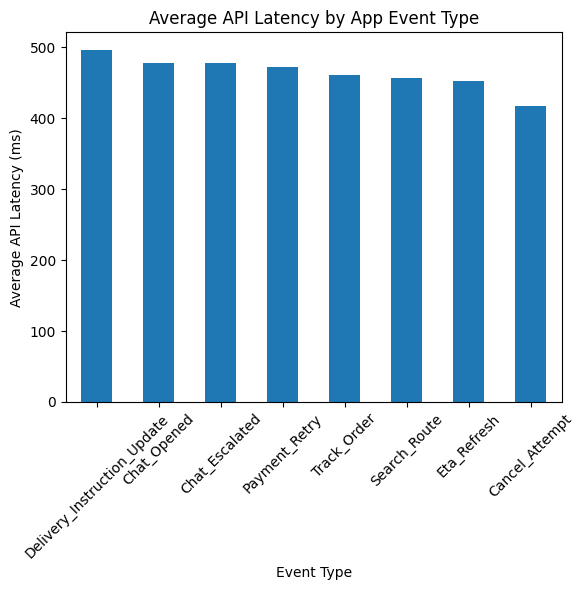

In [ ]:
latency_by_event = app_events_clean.groupby("event_type")["api_latency_ms"].mean().sort_values(ascending=False)

print(latency_by_event)

latency_by_event.plot(kind="bar")
plt.title("Average API Latency by App Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average API Latency (ms)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
orders_clean.to_csv("orders_clean.csv", index=False)
customers_clean.to_csv("customers_clean.csv", index=False)
deliveries_clean.to_csv("deliveries_clean.csv", index=False)
drivers_clean.to_csv("drivers_clean.csv", index=False)
vehicles_clean.to_csv("vehicles_clean.csv", index=False)
hubs_clean.to_csv("hubs_clean.csv", index=False)
complaints_clean.to_csv("complaints_clean.csv", index=False)
incidents_clean.to_csv("incidents_clean.csv", index=False)
app_events_clean.to_csv("app_events_clean.csv", index=False)